# 📖 **Input/Output & Attributes**

> ### 📌 **TL;DR**
>
> This Jupyter notebook has been created to compare different features with several open source Python libraries for rasters management.
>
> This notebook focuses on raster reading/writing and metadata handling (CRS, transform, nodata, dtype, main attributes) across several libraries.</br>
> The goal is to highlight differences in data models, ergonomics, and metadata propagation during I/O operations.
>
> The following libraries will be considered :
>- `rasterio`
>- `rioxarray`
>- `odc-geo`
>- `geoutils`

In [1]:
import rasterio
from rasterio.plot import show

import xarray as xr

import rioxarray

import odc.geo.xr

import geoutils as gu

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import seaborn as sns

import dask

In [2]:
#path to the raster object
raster_path = "../data/rasters/105005005BDEA700-visual.tif"

## **Opening the raster object and checking its main attributes**

### • *rasterio*

The dedicated raster object for `rasterio` is a `rasterio.Dataset`.

We can open our dataset by using the [`rasterio.open()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.html#rasterio.open) function. 

The returned object is a `DatasetReader`, which allows to have access to its metadata and already plot the image if necessary. In addition, with `.open()`, the image is still not loaded into memory (lazy behaviour).

In [3]:
ds_rasterio = rasterio.open(raster_path)

In [4]:
print(type(ds_rasterio))

<class 'rasterio.io.DatasetReader'>


We can directly plot the image to get an overview of it, by using [`show()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.plot.html#rasterio.plot.show) :

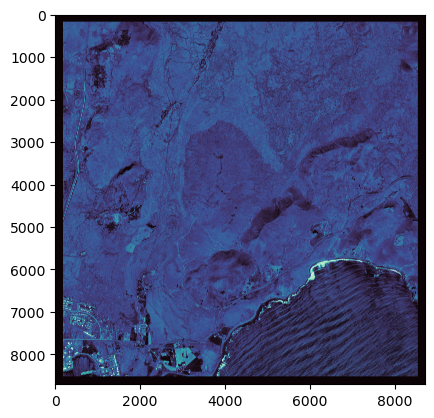

<Axes: >

In [5]:
show(ds_rasterio.read(1), cmap="mako")

Main attributes can be accessed individually :

In [6]:
print(f"""
RASTERIO DATASET ATTRIBUTES\n
Path : {ds_rasterio.name}
Driver : {ds_rasterio.driver}
Number of band(s) : {ds_rasterio.count}
Data type : {ds_rasterio.dtypes}
Size : {ds_rasterio.height} rows x {ds_rasterio.width} columns
CRS : {ds_rasterio.crs}
Bounds : {ds_rasterio.bounds}
Transform : {ds_rasterio.transform}
Nodata : {ds_rasterio.nodata}
""")


RASTERIO DATASET ATTRIBUTES

Path : ../data/rasters/105005005BDEA700-visual.tif
Driver : GTiff
Number of band(s) : 3
Data type : ('uint8', 'uint8', 'uint8')
Size : 8705 rows x 8705 columns
CRS : EPSG:32627
Bounds : BoundingBox(left=429724.7032134462, bottom=7079729.124170403, right=435266.42661960167, top=7085270.840340097)
Transform : | 0.64, 0.00, 429724.70|
| 0.00,-0.64, 7085270.84|
| 0.00, 0.00, 1.00|
Nodata : None



We can also use `.meta.items()` to iterate through each item of the metadata dictionary and improve the output :

In [7]:
print("RASTERIO DATASET ATTRIBUTES\n")
for key, value in ds_rasterio.meta.items():
    print(f"{key} : {value}")

RASTERIO DATASET ATTRIBUTES

driver : GTiff
dtype : uint8
nodata : None
width : 8705
height : 8705
count : 3
crs : EPSG:32627
transform : | 0.64, 0.00, 429724.70|
| 0.00,-0.64, 7085270.84|
| 0.00, 0.00, 1.00|


To access the actual data, we have to use the [`.read()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter.read) method on our DatasetReader previously created. The `.read()` method, unlike `.open`, will load the rasters data into memory.

We can directly specify (or not) the band we want to access, as follows :

In [8]:
data = ds_rasterio.read()

band1 = ds_rasterio.read(1)  # first band

In [9]:
band1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(8705, 8705), dtype=uint8)

The object created is a `numpy.ndarray` containing the value of each pixel of our dataset.

### • *rioxarray*

The dedicated raster object for rioxarray is a `xarray.DataArray` enriched with an accessor `.rio`.

We can use the [`open_rasterio()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.open_rasterio) function to create our `DataArray` object and access its different attributes. As for `rasterio`, `open_rasterio()` will not load the data into memory until requested (lazy behaviour).

One of the advantage of using rioxarray is the possibility to divide our data by `chunks`. Chunks are like small blocks of data that will allow us to work with rasters bigger than our RAM, but also to do parallel computing (giving tasks to different processors at the same time). Instead of loading a full raster into memory, `dask` will only processes the needed chunks.

However, something to keep in mind, is that even if a `xarray.DataArray` is chunked and that a function accepts an xarray object as an input, it does not necessarily mean that it is compatible with `dask`. A function is only dask-compatible if it never accesses concrete values (e.g. `.values`, `np.array`, `.compute()`) and if all operations used are lazy. Otherwise, the computation is triggered prematurely and the advantage of chunking is lost.

To create our chunked array, we need to specify the chunks sizes along each dimension we want, using the `chunks` argument. The size of each chunk along dimension can be given specifically, e.g. `{'x' : 5, 'y' : 5}`, but can also be set to `True` or `"auto"` to be selected automatically. In the example below we will keep it to `True` to select sizes automatically.

In [10]:
da_rioxarray_true = rioxarray.open_rasterio(raster_path, chunks=True)

In [11]:
da_rioxarray_true

<xarray.DataArray (band: 3, y: 8705, x: 8705)> Size: 227MB
dask.array<open_rasterio-90970f8c28240af728403e3b86b108da<this-array>, shape=(3, 8705, 8705), dtype=uint8, chunksize=(1, 8705, 8705), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 70kB 4.297e+05 4.297e+05 ... 4.353e+05 4.353e+05
  * y            (y) float64 70kB 7.085e+06 7.085e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    scale_factor:        1.0
    add_offset:          0.0

Trying to set `chunks` to `"auto"` seems to provide the same result as `True`:

In [12]:
da_rioxarray_auto = rioxarray.open_rasterio(raster_path, chunks="auto")

In [13]:
da_rioxarray_auto

<xarray.DataArray (band: 3, y: 8705, x: 8705)> Size: 227MB
dask.array<open_rasterio-90970f8c28240af728403e3b86b108da<this-array>, shape=(3, 8705, 8705), dtype=uint8, chunksize=(1, 8705, 8705), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 70kB 4.297e+05 4.297e+05 ... 4.353e+05 4.353e+05
  * y            (y) float64 70kB 7.085e+06 7.085e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    scale_factor:        1.0
    add_offset:          0.0

As we can see, the created object is a `xarray.DataArray`, which is a multidimensional array (usually `bands` x `height` x `width`). It contains, among others, the coordinates (actual X/Y values) and the attributes which are metadata of the raster.

Here, we see that our chunks have the size of ~72 MB (`8705 x 8705`), which might be too big for a single image (but not the case for big collections) and can lead to memory overload. This comes from the fact that the original raster is not chunked on disk. [Choosing the good size is not trivial](https://blog.dask.org/2021/11/02/choosing-dask-chunk-sizes), but we consider `2048 x 2048` to be generally a good compromise for most dataset, so we will create a new array with those parameters :

In [14]:
da_rioxarray = rioxarray.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

In [15]:
da_rioxarray

<xarray.DataArray (band: 3, y: 8705, x: 8705)> Size: 227MB
dask.array<open_rasterio-77ae99680ce42830cd9660eb424aa9af<this-array>, shape=(3, 8705, 8705), dtype=uint8, chunksize=(3, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 70kB 4.297e+05 4.297e+05 ... 4.353e+05 4.353e+05
  * y            (y) float64 70kB 7.085e+06 7.085e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    scale_factor:        1.0
    add_offset:          0.0

Now, we see that our chunks are much better distributed along our dataset and have the size of `12MB`, which is more optimized for the memory and parallel computing (the ideal recommanded size is generally between `10~200 MB` depending on the size of the dataset).
However, rechunking is a heavy task that must be avoided if possible and that can take a bit of time, so choosing the good chunk size at the beginning of the computation is essential!

We can now access main attributes individually, as follows :

In [16]:
print(f"""
RIOXARRAY DATASET ATTRIBUTES\n
Dimensions : {da_rioxarray.dims}
Number of band(s) : {da_rioxarray.rio.count}
Data type : {da_rioxarray.dtype}
Shape : {da_rioxarray.shape}
Size : {da_rioxarray.rio.height} rows x {da_rioxarray.rio.width} columns
CRS : {da_rioxarray.rio.crs}
Resolution : {da_rioxarray.rio.resolution()}
Bounds : {da_rioxarray.rio.bounds()}
Transform : {da_rioxarray.rio.transform()}
Nodata : {da_rioxarray.rio.nodata}
Attributes : {da_rioxarray.attrs}
""")


RIOXARRAY DATASET ATTRIBUTES

Dimensions : ('band', 'y', 'x')
Number of band(s) : 3
Data type : uint8
Shape : (3, 8705, 8705)
Size : 8705 rows x 8705 columns
CRS : EPSG:32627
Resolution : (0.6366138318386534, -0.6366130005392807)
Bounds : (429724.7032134462, 7079729.124170403, 435266.42661960167, 7085270.840340097)
Transform : | 0.64, 0.00, 429724.70|
| 0.00,-0.64, 7085270.84|
| 0.00, 0.00, 1.00|
Nodata : None
Attributes : {'DataType': 'Generic', 'AREA_OR_POINT': 'Area', 'RepresentationType': 'ATHEMATIC', 'scale_factor': 1.0, 'add_offset': 0.0}



As in `rasterio`, we can see the main attributes by using `.meta.items()` to iterate over the metadata dictionary.

To access the data, we can use different methods :

In [17]:
da_rioxarray.data

dask.array<open_rasterio-77ae99680ce42830cd9660eb424aa9af<this-array>, shape=(3, 8705, 8705), dtype=uint8, chunksize=(3, 2048, 2048), chunktype=numpy.ndarray>

`.data` will return a dask.array.Array if the input dataset is chunked (and has not been computed). This method is useful to manipulate the data and perform calculations without overload memory.

In [18]:
da_rioxarray.values

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(3, 8705, 8705), dtype=uint8)

`.values` is an eager method that will always return a `numpy.ndarray` by loading all the data into memory, even if the dataset is chunked.

In [19]:
da_rioxarray.compute()

<xarray.DataArray (band: 3, y: 8705, x: 8705)> Size: 227MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(3, 8705, 8705), dtype=uint8)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 70kB 4.297e+05 4.297e+05 ... 4.353e+05 4.353e+05
  * y            (y) float64 70kB 7.085e+06 7.085e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    scale_factor:        1.0
    add_offset:          0.0

`.compute()` will return a `xarray.DataArray` and will compute the graph stored in the array and therefore load all the data into memory.

To access data of a specific pixel, we can use `.isel().item()` (selecting by index/ position) :

In [20]:
da_rioxarray.isel(band=0, y=100, x=200).compute().item()

0

We can also access one specific band by using `.sel()` (selection by real coordinates) and specify the band we want : 

In [21]:
da_rioxarray.sel(band=1)

<xarray.DataArray (y: 8705, x: 8705)> Size: 76MB
dask.array<getitem, shape=(8705, 8705), dtype=uint8, chunksize=(2048, 2048), chunktype=numpy.ndarray>
Coordinates:
    band         int64 8B 1
  * x            (x) float64 70kB 4.297e+05 4.297e+05 ... 4.353e+05 4.353e+05
  * y            (y) float64 70kB 7.085e+06 7.085e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    scale_factor:        1.0
    add_offset:          0.0

### • *odc-geo*

To open a raster, `odc-geo` uses function from other packages. Here we can use the rioxarray `.open_rasterio()` function, as previously we will create chunks of the size of `2048 x 2048`.

Since `odc-geo` is interoperable with data loaded through other libraries, like `rioxarray` as explained [here](https://odc-geo.readthedocs.io/en/latest/intro-xr.html) in the doc, any accessor can be used when imported.

In [7]:
ds_odcgeo = rioxarray.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

In [8]:
ds_odcgeo

<xarray.DataArray (band: 3, y: 8705, x: 8705)> Size: 227MB
dask.array<open_rasterio-77ae99680ce42830cd9660eb424aa9af<this-array>, shape=(3, 8705, 8705), dtype=uint8, chunksize=(3, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 70kB 4.297e+05 4.297e+05 ... 4.353e+05 4.353e+05
  * y            (y) float64 70kB 7.085e+06 7.085e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    DataType:            Generic
    AREA_OR_POINT:       Area
    RepresentationType:  ATHEMATIC
    scale_factor:        1.0
    add_offset:          0.0

Some attributes can be obtained using the odc `.odc` accessor, as follows :

In [9]:
print(f"""ODC-GEO DATASET ATTRIBUTES\n
CRS : {ds_odcgeo.odc.crs}
Transform : {ds_odcgeo.odc.transform}
Geobox : {ds_odcgeo.odc.geobox}
Nodata : {ds_odcgeo.odc.nodata}
""")

ODC-GEO DATASET ATTRIBUTES

CRS : PROJCS["WGS 84 / UTM zone 27N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-21],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32627"]]
Transform : | 0.64, 0.00, 429724.70|
| 0.00,-0.64, 7085270.84|
| 0.00, 0.00, 1.00|
Geobox : GeoBox((8705, 8705), Affine(0.6366138318386534, 0.0, 429724.7032134462,
       0.0, -0.6366130005392807, 7085270.840340097), CRS('PROJCS["WGS 84 / UTM zone 27N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenw

We can see that `odc.geo` concepts differ a bit from the ones developped by `rasterio` and `rioxarray` (and its underlying `GDAL` layer): the transform georeferencing model is completed by a `Geobox`. 

A `Geobox` is an object that contains certain spatial informations (CRS, resolution, affine...), stored as attributes. However it is important to keep in mind that these attributes are not guaranteed to be invariable: they may be modified, lost, or become inconsistent after certain `xarray` operations. It is important not to assume that the GeoBox or spatial metadata remain valid or identical throughout the pipeline, and to explicitly check or rebuild them when necessary.

### • *geoutils*

The dedicated raster object for geoutils is a `geoutils.Raster`.

In [26]:
ds_gu = gu.Raster(raster_path)

In [27]:
ds_gu

Raster(
  data=not_loaded; shape on disk (3, 8705, 8705); will load (3, 8705, 8705)
  transform=| 0.64, 0.00, 429724.70|
            | 0.00,-0.64, 7085270.84|
            | 0.00, 0.00, 1.00|
  crs=EPSG:32627
  nodata=None)

A detailed overview of the main attributes is obtained using the `.info()` function :

In [28]:
print("GEOUTILS DATASET ATTRIBUTES\n")
print(ds_gu.info())

GEOUTILS DATASET ATTRIBUTES

Driver:               GTiff 
Opened from file:     ../data/rasters/105005005BDEA700-visual.tif 
Filename:             ../data/rasters/105005005BDEA700-visual.tif 
Loaded?               False 
Modified since load?  False 
Grid size:            8705, 8705
Number of bands:      3
Data types:           uint8
Coordinate system:    ['EPSG:32627']
Nodata value:         None
Pixel interpretation: Area
Pixel size:           0.6366138318386534, 0.6366130005392807
Upper left corner:    429724.7032134462, 7085270.840340097
Lower right corner:   435266.42661960167, 7079729.124170403

None


Raster image can easily be plotted with [`.plot()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.plot.html#geoutils.Raster.plot):

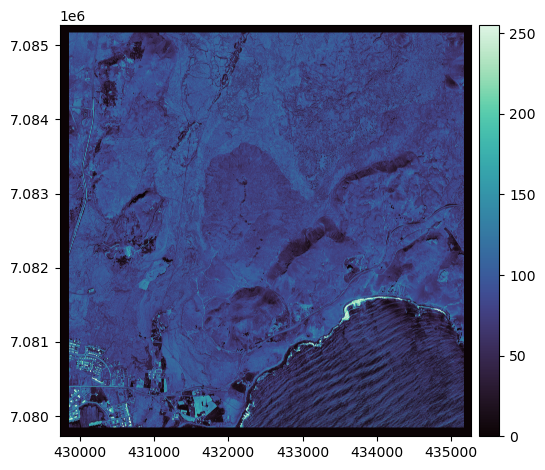

In [29]:
ds_gu.plot(bands=1, cmap="mako")

We can access the data of our raster with `.data` :

In [30]:
ds_gu.data

masked_array(
  data=[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]],
  mask=False,
  fill_value=np.uint64(999999),
  dtype=uint8)

It returns two elements : an array with the actual values for each pixel, and an array with the boolean matrix of the raster (True if the pixel has no data).

## **Access to GCPs (Ground Control Points)**

Access to GCPs are implemented in `rasterio` and `rioxarray`, but not in `odc-geo` and `geoutils`.

Ground Control Points are points that connect a pixel to real coordinates (geographic or projected).

### • *rasterio*

GCPs in rasterio can be accessed with [`.get_gcps()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter.get_gcps).

It will return a tuple in the following format : (`gcp_list`, `gcp_crs`).

In [31]:
with rasterio.open("../data/rasters/IMAGERY.TIF") as src:
    gcps, crs_gcps = src.get_gcps()

In [32]:
print(gcps)
print(crs_gcps)

[GroundControlPoint(row=0.75, col=0.75, x=6.640159451893149, y=48.800859824056396, z=0.0, id='1', info=''), GroundControlPoint(row=0.75, col=3000.25, x=7.454915000699646, y=48.662596222590906, z=0.0, id='2', info=''), GroundControlPoint(row=3000.25, col=3000.25, x=7.251946748303512, y=48.140546184408734, z=0.0, id='3', info=''), GroundControlPoint(row=3000.25, col=0.75, x=6.445330667098447, y=48.278036018890184, z=0.0, id='4', info='')]
EPSG:4326


Each GCP is an object `rasterio.control.GroundControlPoint` containing :
- *row, col*
- *x, y, z*
- *id, info*

### • *rioxarray*

In [33]:
ds_rioxarray = rioxarray.open_rasterio("../data/rasters/IMAGERY.TIF")

With rioxarray, we can have access to GCPs by using the `.rio` accessor, with [`.get_gcps()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.rioxarray.XRasterBase.get_gcps) as follows :

In [34]:
ds_rioxarray.rio.get_gcps()

[GroundControlPoint(row=0.75, col=0.75, x=6.640159451893149, y=48.800859824056396, z=0.0, id='1', info=''),
 GroundControlPoint(row=0.75, col=3000.25, x=7.454915000699646, y=48.662596222590906, z=0.0, id='2', info=''),
 GroundControlPoint(row=3000.25, col=3000.25, x=7.251946748303512, y=48.140546184408734, z=0.0, id='3', info=''),
 GroundControlPoint(row=3000.25, col=0.75, x=6.445330667098447, y=48.278036018890184, z=0.0, id='4', info='')]

It returns a list of all GCPs with their coordinates.

## **Access to RPCs (Rational Polynomial Coefficients)**

Access to RPCs are only implemented in rasterio.

RPCs can also be used to georeference a raster.

### • *rasterio*

In rasterio, they can be checked using [`.rpcs`](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter.rpcs).

In [35]:
with rasterio.open("../data/rasters/IMG_SPOT7_MS_201602150257025_SEN_1671661101_R1C1.JP2") as src:
    rpcs = src.rpcs

In [36]:
print(rpcs)

RPC(height_off=500.0, height_scale=500.0, lat_off=-6.18850636, lat_scale=0.23683088, line_den_coeff=[1.0, 7.695685183846994e-09, -3.437085940983034e-09, -4.867847610169121e-11, 3.794060066187665e-08, -1.143318180368229e-09, -2.006823121377377e-10, 2.540265745155602e-09, 8.468011204232001e-08, -4.110084301544468e-13, -3.763778848686403e-11, -1.462843733480328e-10, -6.203309291374671e-09, 8.930695805690373e-13, -1.746047399695524e-11, -2.062893589205057e-10, -2.552319421933559e-12, 1.02740095636594e-10, -6.008220910788273e-12, -2.84925177658875e-14], line_num_coeff=[-0.002742115700048922, 0.1640175671616054, -1.173191573617339, -0.00937904938548186, 0.001471806164933382, 4.181651945404631e-05, -0.0002249637497178812, 0.0006215566372489882, 0.0006940730833862084, -1.037664286007259e-06, 3.453457923251534e-07, -2.543241124443991e-06, -2.257139119889496e-05, 6.245019479721916e-09, 1.203928439338081e-05, 3.612351860075633e-05, -2.753299206009975e-08, 1.682294238768133e-07, 2.703660784376137e

In [37]:
print(type(rpcs))

<class 'rasterio.rpc.RPC'>


It will return an instance of `rasterio.rpc.RPC` if there are RPCs, or empty otherwise.

## **Save to local disk**

In this section, we will demonstrate how to save our raster locally.

### • *rasterio*

First, we need to get all metadata of our raster with the profile.

Then, to save a raster locally with rasterio, we will use `.open()` to open our raster as `'w'` (writing mode).

We can then save the output file with the `.write()` function :

In [38]:
with rasterio.open(raster_path) as src:
    data = src.read()
    profile = src.profile

    profile.update(
        dtype=rasterio.uint8,
        count=3,
        compress="JPEG")

    with rasterio.open('../outputs/rasterio_output.tif', 'w', **profile) as dst:
        dst.write(data)

### • *rioxarray*

With rioxarray, we can save our raster locally with the function [`to_raster()`](https://corteva.github.io/rioxarray/html/rioxarray.html#rioxarray.raster_array.RasterArray.to_raster).

Unlike rasterio, no need to save metadata first :

In [39]:
with rioxarray.open_rasterio(raster_path) as src:
    src.rio.to_raster("../outputs/rioxarray_raster_output.tif", compress="JPEG")

### • *geoutils*

Using geoutils, we can save our raster locally by using the [`save()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.save.html#geoutils.Raster.save) function:

In [40]:
ds_gu.save("../outputs/geoutils_raster.tif")

## **Save to COG (Cloud-Optimized GeoTIFF) format**

A Cloud-Optimized GeoTIFF (COG) is a regular GeoTIFF file optimized for remote access, structured to be read efficiently from the cloud, without the need to download the entire file.

### • *rasterio*

Since recent versions of GDAL (> 3.1), rasterio can use the driver `COG` when saving a file.

In [41]:
from rasterio.shutil import copy as rio_copy

input_raster_path = raster_path
output_rasterio_cog = "../outputs/rasterio_cog.tif"

# COG options
cog_profile = dict(
    driver="COG",
    compress="LZW",
    blocksize=512,
    overview_resampling="average"
)

rio_copy(
    input_raster_path,
    output_rasterio_cog,
    **cog_profile
)

We can verify the validity of our COG file newly created using the `cog_validate()` function from the `rio-cogeo` library.

In [43]:
from rio_cogeo.cogeo import cog_validate

cog_validate(output_rasterio_cog, strict=True)

(True, [], [])

### • *rioxarray*

It is possible to save COG files using rioxarray as well with the function [`to_raster()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html#rasterio.io.BufferedDatasetWriter.rpcs) since it integrates the driver `COG` as for rasterio :

In [44]:
output_rioxarray_cog = "../outputs/rioxarray_cog.tif"

with rioxarray.open_rasterio(raster_path) as src:
    src.rio.to_raster(
        output_rioxarray_cog,
        driver="COG",
        compress="LZW",
        blocksize=512,
        BIGTIFF="IF_SAFER",
        overview_resampling="average"
    )

Once again, we can verify the validity of the COG file with `rio-cogeo` :

In [45]:
cog_validate(output_rioxarray_cog, strict=True)

(True, [], [])

### • *odc-geo*

`odc-geo` includes several functions to save COG files, with or without `dask`.

- Without dask, using the [`write_cog()`](https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.write_cog.html) function:

In [3]:
from odc.geo.xr import write_cog

In [5]:
da_odcgeo = rioxarray.open_rasterio(raster_path)

output_odcgeo_cog = "../outputs/odcgeo_cog.tif"

write_cog(da_odcgeo, output_odcgeo_cog)

WindowsPath('../outputs/odcgeo_cog.tif')

We can check the validity using :

In [8]:
cog_validate(output_odcgeo_cog, strict=True)

(True, [], [])

### • *geoutils*

With geoutils, we will be using the `.save` function, but this time we specify `driver="COG` as an argument :

In [50]:
ds_gu.save("../outputs/geoutils_cog.tif", driver="COG")

In [51]:
cog_validate("../outputs/geoutils_cog.tif", strict=True)

(True, [], [])